# Idea

Solve landau zener problem exactly


In [1]:
import sys

sys.path.append("../../src/")

from common_imports import *


In [9]:
sz = array([[1,0],[0,-1]],dtype=complex)
sx = array([[0, 1],[1,0]],dtype=complex)
sy = array([[0,-1j],[1j,0]],dtype=complex)

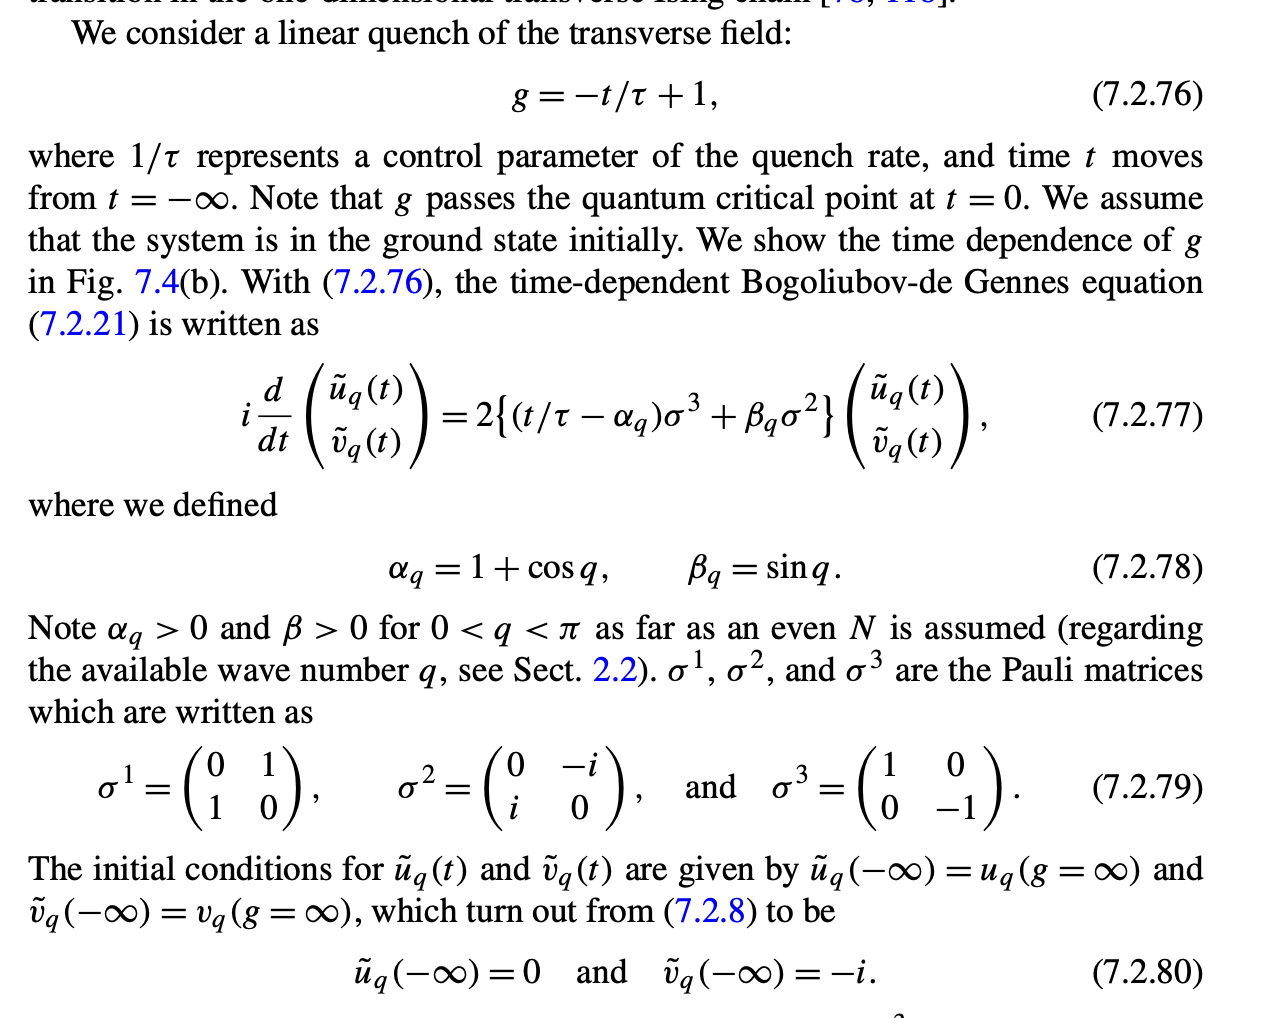

In [336]:
def a(q):
    return 1+ cos(q)
def b(q):
    return sin(q)
def quench(t,tau):
    return (t/tau)**(1)
def BdG(t,tau,q):
    return 2*((quench(t,tau)-a(q))*sz+b(q)*sy)
###Initial state generation 

def a0(q,g):
    return g+ cos(q)
def b0(q,g):
    return sin(q)
def om(q,g):
    return sqrt(g*g+2*g*cos(q)+1)
def U0(q,g):
    u = (a0(q,g)-om(q,g))
    v = b0(q,g)

    denom = sqrt(2*om(q,g)*(om(q,g)-a0(q,g)))
    return array([u/denom,v/denom],dtype=complex)
from scipy.integrate import solve_ivp

def BdG_Evolution(t,U,tau,q):
    return -1j*BdG(t,tau,q)@U

from numpy import conj
def nq(sol):
    u = sol.y[0]
    v = sol.y[1]
    t = sol.t
    dat=[]
    for ti,ui,vi in zip(t,u,v):
        g = 1 - quench(ti,tau)
        ug,vg = U0(q,g)
        S = array([[ui,-conj(vi)],[vi,conj(ui)]],dtype=complex)
        R = array([[ug,-1j*vg],[-1j*vg,ug]],dtype=complex)
        dat.append( (conj(S).T@conj(R).T@sz@R@S)[1,1]+1 )
    return array(dat)

In [337]:
U0(.1,1)

array([-0.0249974 +0.j,  0.99968752+0.j])

In [338]:
1-quench(t_eval,tau)

array([ 2.       ,  1.9989998,  1.9979996, ..., -2.9979996, -2.9989998,
       -3.       ], shape=(5000,))

In [339]:
np.linalg.eigh(BdG(t0,tau,q))[1][:,0]

array([-0.97324899-0.j        ,  0.        +0.22975292j])

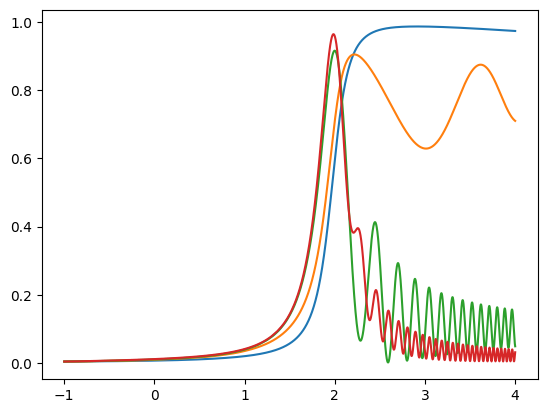

In [345]:
taus = [.1,1,10,20]
for tau in taus:
   # tau = 1
    t0 = -tau*1
    q = pi/16
    V0 = np.linalg.eigh(BdG(t0,tau,q))[1][:,1]#U0(q,1-quench(t0,tau))
    t_eval = np.linspace(t0, 4*tau, 5000)
    sol= solve_ivp(BdG_Evolution,
                [t0,4*tau],
                V0,
                args=(tau,q),
                t_eval=t_eval)

    u = sol.y[0]
    v = sol.y[1]

   # plot(t_eval/tau,abs(u))
   # plot(t_eval/tau,abs(v))
    plot(t_eval/tau,nq(sol)/2)


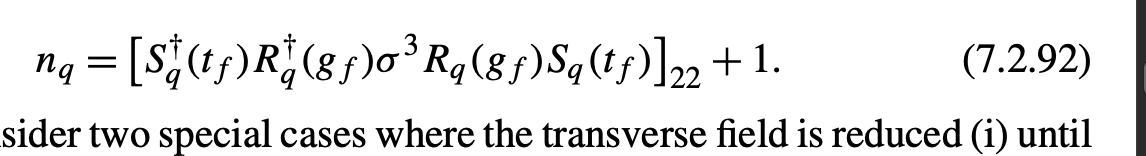

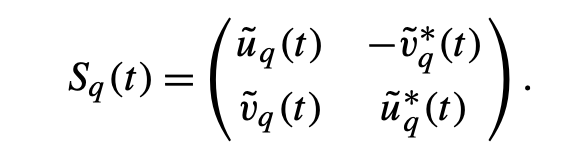

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


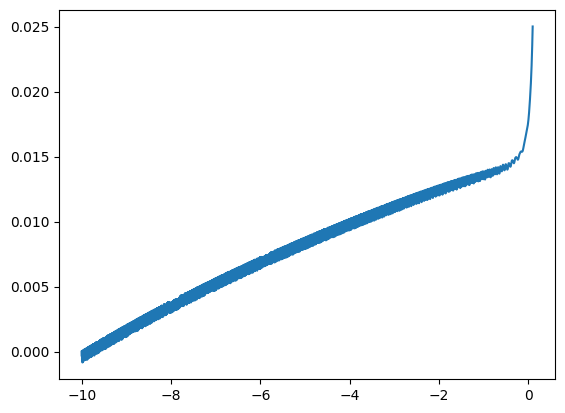